I thought it would be good practice to try and recreate the doppler testing file in Julia.  According to the style guide, it is recommended to try and write the program as a series of functions because they tend to run much faster in Julia than more top level code.

In [1]:
using Distributions, Random, Plots, LaTeXStrings

In [5]:
doppler_shift(vs, freq, c) = @. vs * freq / c

doppler_shift (generic function with 1 method)

In [2]:
# Define our constants
m = 85 * 1.67e-27   # mass of Rb 85 atom converted to kg
kb = 1.381e-23      # Boltzmann's constant in J/K
T = 300             # temperature in K
c = 3e8             # speed of light in m/s
f01 = 385e3         # frequency of |1> in GHz
f02 = 625e3         # frequency of |2> in GHz
f03 = 10            # frequency of |3> in GHz

# Calculate standard deviation of our velocity distribution
σ = sqrt(kb * T / m);

In [3]:
# Specify the seed and create the distribution
Random.seed!(0)
d = Normal(0.0, σ)

# Generate the random samples for v
v_samples = rand(d, 100);

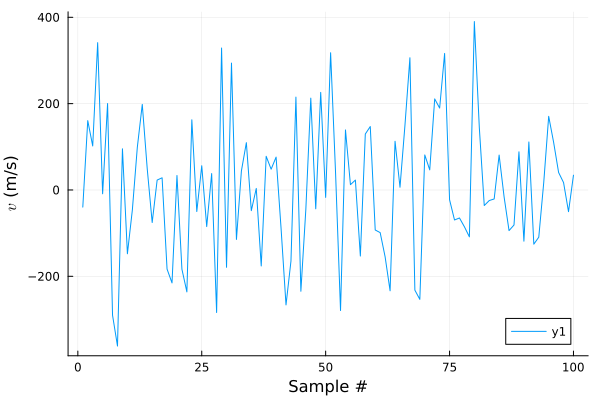

In [4]:
plot(v_samples)
xlabel!("Sample #")
ylabel!(L"$v$ (m/s)")

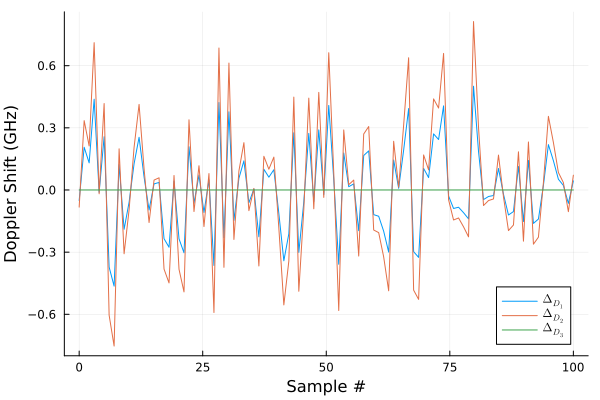

In [10]:
x = range(0, 100, length=100)
ΔD1 = doppler_shift(v_samples, f01, c)
ΔD2 = doppler_shift(v_samples, f02, c)
ΔD3 = doppler_shift(v_samples, f03, c)
plot(x, [ΔD1, ΔD2, ΔD3], label=[L"$\Delta_{D_1}$" L"$\Delta_{D_2}$" L"$\Delta_{D_3}$"])
xlabel!("Sample #")
ylabel!("Doppler Shift (GHz)")

In [ ]:
# Define parameters for transmission spectrum calculation
